In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



In [21]:
np.random.seed(21)

df = pd.DataFrame({
    "Student_ID": range(1001,2001),
    "Attendance": np.random.randint(50,101,1000),
    "Assignment": np.random.randint(40,101,1000),
    "Study_Hours": np.random.randint(1,11,1000),
    "Participation": np.random.randint(1,11,1000)
})

df["Exam_Score"] = (
    0.30*df["Attendance"] +
    0.35*df["Assignment"] +
    2.5*df["Study_Hours"] +
    1.5*df["Participation"] +
    np.random.randint(-10,11,1000)
)

df["Exam_Score"] = df["Exam_Score"].clip(35,100).round().astype(int)

df.head()

,Student_ID,Attendance,Assignment,Study_Hours,Participation,Exam_Score
0,1001,59,91,9,9,85
1,1002,65,79,5,8,74
2,1003,54,91,2,3,66
3,1004,98,55,9,5,85
4,1005,98,86,8,5,90


In [22]:
def classify_student(score):
    if score >= 85:
        return "High"
    elif score >= 70:
        return "Medium"
    return "Low"

df["Performance"] = df["Exam_Score"].apply(classify_student)
df.head()

,Student_ID,Attendance,Assignment,Study_Hours,Participation,Exam_Score,Performance
0,1001,59,91,9,9,85,High
1,1002,65,79,5,8,74,Medium
2,1003,54,91,2,3,66,Low
3,1004,98,55,9,5,85,High
4,1005,98,86,8,5,90,High


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Student_ID     1000 non-null   int64
 1   Attendance     1000 non-null   int32
 2   Assignment     1000 non-null   int32
 3   Study_Hours    1000 non-null   int32
 4   Participation  1000 non-null   int32
 5   Exam_Score     1000 non-null   int64
 6   Performance    1000 non-null   str  
dtypes: int32(4), int64(2), str(1)
memory usage: 43.3 KB


In [24]:
df.describe()

,Student_ID,Attendance,Assignment,Study_Hours,Participation,Exam_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1500.500000,75.327000,69.051000,5.626000,5.613000,69.277000
std,288.819436,14.657999,17.549826,2.805351,2.880196,12.543509
min,1001.000000,50.000000,40.000000,1.000000,1.000000,38.000000
25%,1250.750000,62.000000,54.000000,3.000000,3.000000,60.000000
50%,1500.500000,76.000000,69.000000,6.000000,6.000000,69.000000
75%,1750.250000,88.000000,84.000000,8.000000,8.000000,79.000000
max,2000.000000,100.000000,100.000000,10.000000,10.000000,100.000000


In [25]:
print(df.isnull().sum())


Student_ID       0
Attendance       0
Assignment       0
Study_Hours      0
Participation    0
Exam_Score       0
Performance      0
dtype: int64


In [26]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [27]:
summary = df.groupby("Performance").mean(numeric_only=True)
print(summary)

              Student_ID  Attendance  Assignment  Study_Hours  Participation  \
Performance                                                                    
High         1479.459677   84.233871   82.798387     8.000000       7.298387   
Low          1500.978131   71.017893   62.411531     4.286282       4.858847   
Medium       1506.849866   78.176944   73.434316     6.643432       6.069705   

             Exam_Score  
Performance              
High          89.758065  
Low           59.071571  
Medium        76.230563  


In [28]:
risk_students = df.query("Attendance < 70 or Exam_Score < 60")
print(risk_students)
print("Total At-Risk Students:", len(risk_students))

     Student_ID  Attendance  Assignment  Study_Hours  Participation  \
0          1001          59          91            9              9   
1          1002          65          79            5              8   
2          1003          54          91            2              3   
7          1008          99          40            4              3   
8          1009          60          90            2              6   
..          ...         ...         ...          ...            ...   
985        1986          66          98            3              1   
987        1988          69          40            2              1   
990        1991          61         100            8              9   
995        1996          60          73            1             10   
996        1997          78          42            4              1   

     Exam_Score Performance  
0            85        High  
1            74      Medium  
2            66         Low  
7            56         Low

In [29]:
x = df[["Attendance","Assignment","Study_Hours","Participation"]]
y = df["Performance"]


In [30]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=42)


In [31]:
tree_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)
tree_classifier.fit(x_train,y_train)

y_pred = tree_classifier.predict(x_test)


In [32]:
print("Accuracy:", accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))


Accuracy: 0.675
[[11  0 20]
 [ 0 69 23]
 [ 5 17 55]]
              precision    recall  f1-score   support

        High       0.69      0.35      0.47        31
         Low       0.80      0.75      0.78        92
      Medium       0.56      0.71      0.63        77

    accuracy                           0.68       200
   macro avg       0.68      0.61      0.62       200
weighted avg       0.69      0.68      0.67       200



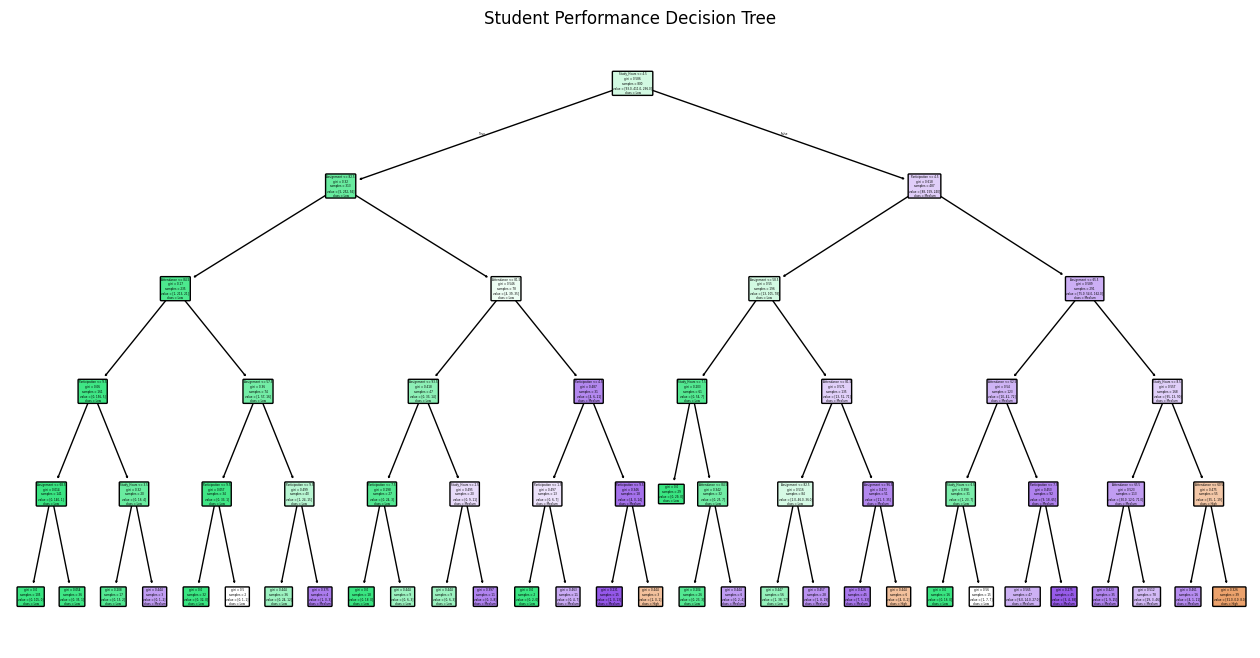

In [33]:
plt.figure(figsize=(16,8))
plot_tree(tree_classifier,
          feature_names=x.columns,
          class_names=tree_classifier.classes_,
          filled=True,
          rounded=True)
plt.title("Student Performance Decision Tree")
plt.show()